# Motion-Corrected Image Reconstruction (MCIR)


In [1]:
__version__ = '0.2.0'

# import engine module
import sirf.Gadgetron as pMR
from sirf.Utilities import examples_data_path
# from sirf_exercises import exercises_data_pathtoken
import sirf.Reg as pReg


from cil.framework import  AcquisitionGeometry, BlockDataContainer, BlockGeometry
from cil.optimisation.functions import Function, OperatorCompositionFunction, SmoothMixedL21Norm, L1Norm, L2NormSquared, BlockFunction, MixedL21Norm, IndicatorBox, TotalVariation, LeastSquares, ZeroFunction
from cil.optimisation.operators import GradientOperator, BlockOperator, ZeroOperator, CompositionOperator,LinearOperator
from cil.optimisation.algorithms import PDHG, FISTA, GD, SPDHG
from cil.plugins.ccpi_regularisation.functions import FGP_TV

# import further modules
import os
import numpy as np
import scipy.signal as sp_signal

import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

import functools

In [2]:
# Plotting function
data_path = '/home/jovyan/devel/SIRF-Contribs/src/notebooks/'
os.chdir(data_path)
import utils
from utils import plot_rpe_3d, plot_rpe_3d_simple, save_itrobj
print ("Ciao")


Ciao


In [3]:
import importlib
importlib.reload(utils)
from utils import plot_rpe_3d, plot_rpe_3d_simple, saveCallback, add_HORIZONTAL_phase_shift

In [4]:
############# SETUP #################
# number of motion states
Nms = 6
# max
max_shift = 20.
# setup linear shifts
shifts = np.linspace(0, 1, Nms) * max_shift

## Recon parameters
n_epochs = 100
# factor in front of L2Norm
omega = 0.5
# regularisation parameter
alpha = 2e-5

recons = 'recons_ignore-acq_2'

In [5]:
# data_path = exercises_data_path('MR')

filename = os.path.join(data_path, '3D_GRPE_no_motion.h5')

In [6]:
# Load in the data
acq_data = pMR.AcquisitionData(filename)
acq_data.sort_by_time()

Started reading acquisitions from /home/jovyan/devel/SIRF-Contribs/src/notebooks/3D_GRPE_no_motion.h5
0%..10%..20%..31%..40%..50%..61%..70%..80%..90%..
Finished reading acquisitions from /home/jovyan/devel/SIRF-Contribs/src/notebooks/3D_GRPE_no_motion.h5


In [7]:
csm = pMR.CoilSensitivityData()
csm.smoothness = 100
csm.calculate(acq_data) 

E = pMR.AcquisitionModel(acqs=acq_data, imgs=csm)
E.set_coil_sensitivity_maps(csm)


# Adding horizontal phase shift

## Create Motion States

In [8]:
import importlib
importlib.reload(utils)

from utils import split_data_with_horizontal_shifts, create_AcquisitionModel_for_each_motion_state 

acq_ms = split_data_with_horizontal_shifts(acq_data, shifts)

E_ms = create_AcquisitionModel_for_each_motion_state(acq_ms, csm)




In [9]:
import functools
im_fista_ms = [0] * Nms

im_ms = E_ms[0].inverse(acq_ms[0])

for ind in range(Nms):

    # Starting image
    x_init = im_ms.clone()
    x_init.fill(0.0)

    # Objective function
    f = LeastSquares(E_ms[ind], acq_ms[ind], c=1)
    G = ZeroFunction()

    # Set up FISTA for least squares
    fista = FISTA(initial=x_init, f=f, g=G)
    fista.max_iteration = 100
    fista.update_objective_interval = 5

    # Run FISTA
    sc = functools.partial(saveCallback, fista, f"FISTA_L2_ms_{ind}", os.path.join(data_path, recons, f'MS_{Nms}'))
    fista.run(10, verbose=1, callback=sc)
    
    # Get result
    im_fista_ms[ind] = fista.get_output()

     Iter   Max Iter     Time/Iter            Objective
                               [s]                     
        0        100         0.000          5.55129e-03
        5        100         9.407          3.16631e-04
       10        100         9.273          3.96703e-05
-------------------------------------------------------
       10        100         9.273          3.96703e-05
Stop criterion has been reached.

     Iter   Max Iter     Time/Iter            Objective
                               [s]                     
        0        100         0.000          5.70587e-03
        5        100         8.719          3.05595e-04
       10        100         8.814          5.40247e-05
-------------------------------------------------------
       10        100         8.814          5.40247e-05
Stop criterion has been reached.

     Iter   Max Iter     Time/Iter            Objective
                               [s]                     
        0        100         0.000  

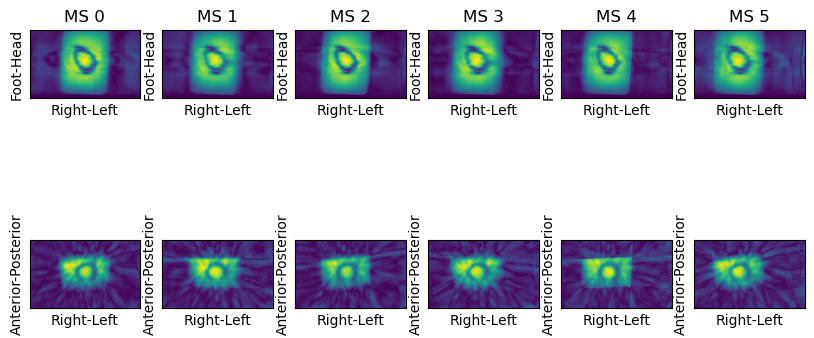

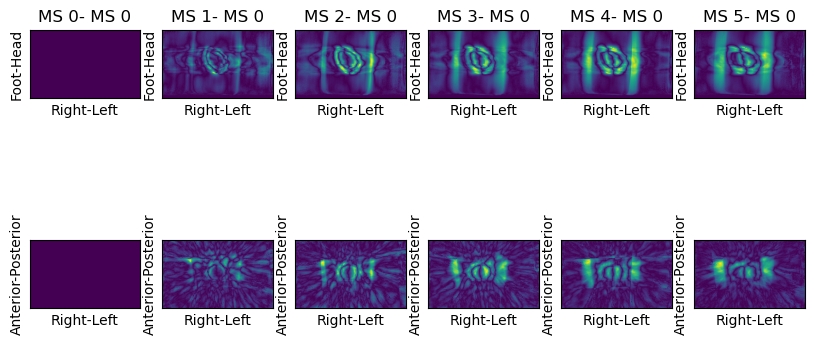

In [10]:
# Prepare results
#%matplotlib inline
im_fista_ms_arr = []
im_fista_diff_arr = []
for ind in range(Nms):
    im_fista_ms_arr.append(im_fista_ms[ind].as_array())
    im_fista_diff_arr.append(np.abs(im_fista_ms[ind].as_array()) - np.abs(im_fista_ms_arr[0]))
    
# Visualise different motion states
plot_rpe_3d_simple(im_fista_ms_arr[:], [64, 64], [ f'MS {ms}' for ms in range(Nms) ])
print('\n')
# Visualise difference to first motion state
plot_rpe_3d_simple(im_fista_diff_arr[:], [64, 64], [f'MS {ms}- MS 0'  for ms in range(Nms) ])

## Create Motion Vector fields from known shifts

In [11]:
class NiftyResampleWithNormCache(pReg.NiftyResample):

    def __init__(self, *args, **kwargs):
        self._norm = None
        super().__init__(*args, **kwargs)
        
    def norm(self):
        if self._norm is not None:
            return self._norm
        self._norm = self.calculate_norm()
        return self._norm

    def calculate_norm(self):
        return LinearOperator.PowerMethod(self, method='composed_with_adjoint')

# Motion fransformation object
mf_resampler = [0] * Nms

# Forward transformation (i.e. reference image transformed to current motion state)
im_forward = [0] * Nms

# Backward transformation (i.e. current motion image transformed to reference motion state)
im_backward = [0] * Nms

tms = []
import logging

for shift in shifts:
    # fix the pixel spacing
    spacing = im_fista_ms[0].get_geometrical_info().get_spacing()
    # There is inconsistency in SIRF wrt to the order of the dimensions
    # here we rely on the fact that the spacing is uniform.
    uniform = (spacing[0] == spacing[1]) and (spacing[1] == spacing[2]) and (spacing[0] == spacing[2])
    if not uniform:
        logging.warn('The spacing is not uniform. The results might be incorrect.')
    t_x=shift * spacing[0]
    t_y=0
    tm = pReg.AffineTransformation(np.array(\
            [[1, 0, 0, t_x], \
             [0, 1, 0, t_y], \
             [0, 0, 1, 0  ], \
             [0, 0, 0, 1  ]]))
    tms.append(tm)
    
for ind in range(Nms):

    # Create resampler
    mf_resampler[ind] = NiftyResampleWithNormCache()
    # check units used by the resampler
    mf_resampler[ind].set_reference_image(im_fista_ms[0])
    mf_resampler[ind].set_floating_image(im_fista_ms[ind])
    mf_resampler[ind].add_transformation(tms[ind])
    mf_resampler[ind].set_padding_value(0)
    mf_resampler[ind].set_interpolation_type_to_linear()

    im_forward[ind] = mf_resampler[ind].forward(im_fista_ms[0])
    im_backward[ind] = mf_resampler[ind].backward(im_fista_ms[ind])

## Let's look at the backward transformed images (i.e. the images transformed to the reference motion state).

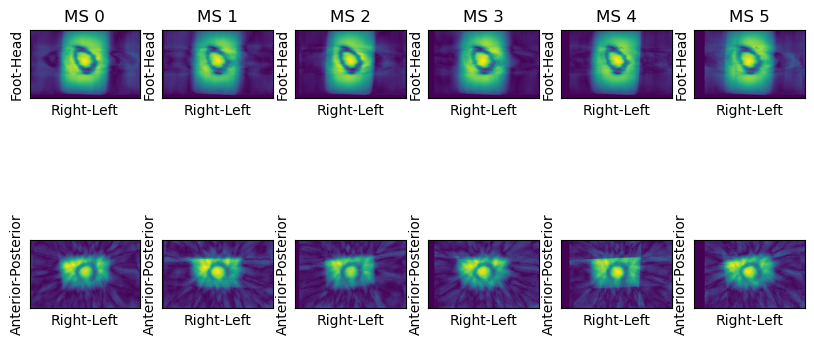

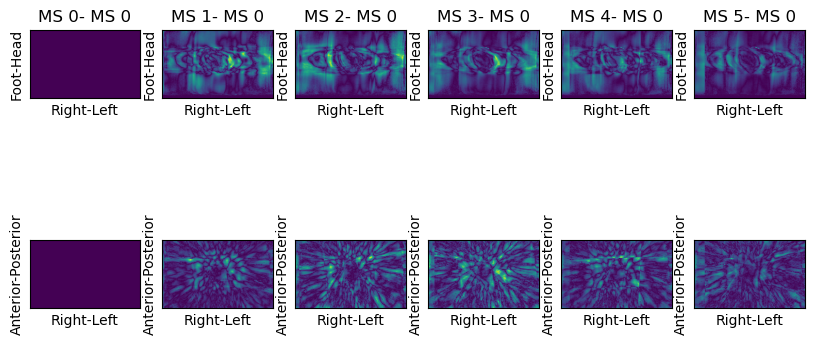

In [12]:
# Prepare results
%matplotlib inline
im_backward_arr = []
im_backward_diff_arr = []
for ind in range(Nms):
    im_backward_arr.append(im_backward[ind].as_array())
    im_backward_diff_arr.append(np.abs(im_backward[ind].as_array()) - np.abs(im_backward[0].as_array()))
    
# Visualise different motion states transformed to reference motion state
plot_rpe_3d_simple(im_backward_arr, [64, 64], [ f'MS {ms}' for ms in range(Nms) ])

# Visualise difference to first motion state
plot_rpe_3d_simple(im_backward_diff_arr, [64, 64], [f'MS {ms}- MS 0'  for ms in range(Nms) ])


## Modifications to CIL/SIRF (check comments to see whether cell(s) can be removed)

In [14]:
# this cell is to be removed if using newer CIL version that implements 1470 (leave default, symmetric=False)

# Overriding PowerMethod to ensure no bug
class MyLinearOperator(LinearOperator):
    
    def PowerMethod(operator, max_iteration=10, initial=None, tolerance = 1e-5,  return_all=False):

        symmetric = False
        try:
            if operator.domain_geometry()==operator.range_geometry():
                symmetric = True
        except AssertionError:
            pass

        if initial is None:
            x0 = operator.domain_geometry().allocate('random')
        else:
            x0 = initial.copy()

        y_tmp = operator.range_geometry().allocate()
  
        # Normalize first eigenvector
        x0_norm = x0.norm()
        x0 /= x0_norm
        
        # initial guess for dominant eigenvalue
        eig_old = 1.
        eig_list = []
        diff = np.finfo('d').max
        
        i=0
        while (i < max_iteration and diff > tolerance):
            i+=1
            operator.direct(x0, out = y_tmp)            
            operator.adjoint(y_tmp,out=x0)
            
            # Get eigenvalue using Rayleigh quotient: denominator=1, due to normalization
            x0_norm = x0.norm()      
            x0 /= x0_norm

            eig_new =  np.abs(x0_norm)
            if not symmetric:
                eig_new = np.sqrt(eig_new)

            eig_list.append(eig_new)
            eig_old = eig_new      
        
        if return_all:
            return eig_new, i, x0, eig_list
        else:
            return eig_new
        
    def calculate_norm(self):
        
        r""" Returns the norm of the LinearOperator calculated by the PowerMethod with default values.
                """
        return MyLinearOperator.PowerMethod(self)            


In [15]:
# this cell is to be removed if using newer SIRF version that implements 1182
from packaging import version as pversion
if pversion.parse(sirf.__version__) < pversion.parse('3.5.0'): 
    def NiftyResampler_norm(x):
        out = LinearOperator.PowerMethod(x)
        return out

    setattr(pReg.NiftyResampler, 'norm', NiftyResampler_norm)

In [16]:
# this cell is to be removed if using newer CIL version that implements 1472

if pversion.parse(cil.version.version) < pversion.parse('23.1.0'):
    def CompositionOperator_norm(comp_operator):
        out = 1.
        for factor in comp_operator.operators:
            out = out * factor.norm()
        return out

    setattr(CompositionOperator, 'norm', CompositionOperator_norm)

In [17]:
# this cell is to be removed if using newer CIL version that implements 1479


import types   # import needed for later
if pversion.parse(cil.version.version) < pversion.parse('23.1.0'):
    # Overriding proximal, to remove call to function "check_input"
    def new_proximal(self, x, tau, out=None):
        arr = x.as_array()
        if np.iscomplexobj(arr):
            # do real and imag part indep
            in_arr = np.asarray(arr.real, dtype=np.float32, order='C')
            res, info = self.proximal_numpy(in_arr, tau)
            arr.real = res[:]
            in_arr = np.asarray(arr.imag, dtype=np.float32, order='C')
            res, info = self.proximal_numpy(in_arr, tau)
            arr.imag = res[:]
            self.info = info
            if out is not None:
                out.fill(arr)
            else:
                out = x.copy()
                out.fill(arr)
                return out
        else:
            arr = np.asarray(x.as_array(), dtype=np.float32, order='C')
            res, info = self.proximal_numpy(arr, tau)
            self.info = info
            if out is not None:
                out.fill(res)
            else:
                out = x.copy()
                out.fill(res)
                return out

## MCIR with PDHG

In [18]:
from datetime import datetime

In [19]:
C = [CompositionOperator(am, res) for am, res in zip(*(E_ms, mf_resampler))]
A = BlockOperator(*C)

acq_ms_block = BlockDataContainer(*acq_ms)
# x_init = A.adjoint(acq_ms_block)
# x_init.fill(0.0)

F_all_subs = []
for i in acq_ms:
    F_all_subs.append(omega*L2NormSquared(b=i))
    
F = BlockFunction(*F_all_subs)

In [20]:
G = alpha * FGP_TV(device='cpu', nonnegativity=False)

if pversion.parse(cil.version.version) < pversion.parse('23.1.0'):
    # this line is to be removed if using newer CIL version that implements 1479
    G.proximal = types.MethodType(new_proximal, G)
    print("proximal updated")

nn = G.proximal(im_fista_ms[0], tau=1.0)
plot_rpe_3d_simple([nn.as_array()], [64, 64], ['Proximal'])




In [21]:

pdhg_2 = PDHG(
            f=F, g=G, operator=A,
            max_iteration=n_epochs,
            update_objective_interval=1)


/opt/SIRF-SuperBuild/INSTALL/python/cil/optimisation/algorithms/PDHG.py:406: UserWarning: Convergence criterion of PDHG for scalar step-sizes is not satisfied.
  warnings.warn("Convergence criterion of PDHG for scalar step-sizes is not satisfied.")


In [22]:
sc = functools.partial(saveCallback, pdhg_2, f"PDHG_TV_{Nms:02d}ms", os.path.join(data_path, recons, f'MS_{Nms}'))
    
start = datetime.now()
pdhg_2.run(15, verbose=2, callback=sc)

pdhg_2.update_objective_interval = 5
pdhg_2.run(5, verbose=2, callback=sc)

pdhg_2.update_objective_interval = 10
pdhg_2.run(verbose=2, callback=sc)

end = datetime.now()

pdhg_2_time = end-start

save_itrobj(pdhg_2, data_path, recons, Nms)

     Iter   Max Iter     Time/Iter        Primal          Dual     Primal-Dual
                               [s]     Objective     Objective             Gap


/opt/SIRF-SuperBuild/INSTALL/python/cil/plugins/ccpi_regularisation/functions/regularisers.py:118: ComplexWarning: Casting complex values to real discards the imaginary part
  in_arr = np.asarray(x.as_array(), dtype=np.float32, order='C')


        0        100         0.000    1.69328e-02  -0.00000e+00    1.69328e-02
        1        100       156.128    5.74506e-03 8.46869e-04+3.15086e-13j4.89819e-03-3.15086e-13j
        2        100       159.403    3.28971e-03 7.85438e-04+1.53196e-07j2.50427e-03-1.53196e-07j
        3        100       167.256    1.71610e-03 7.23623e-04-3.41600e-07j9.92480e-04+3.41600e-07j
        4        100       173.422    9.66591e-04 7.26250e-04-2.68753e-07j2.40342e-04+2.68753e-07j
        5        100       170.627    9.78957e-04 7.00552e-04+1.03181e-06j2.78405e-04-1.03181e-06j
        6        100       168.913    1.30262e-03 6.22704e-04+1.44494e-06j6.79915e-04-1.44494e-06j
        7        100       171.264    1.55589e-03 5.03586e-04+1.04290e-06j1.05231e-03-1.04290e-06j
        8        100       174.482    1.57528e-03 3.73862e-04+4.21374e-07j1.20142e-03-4.21374e-07j
        9        100       179.011    1.39867e-03 2.59199e-04-2.37142e-07j1.13947e-03+2.37142e-07j
       10        100       171

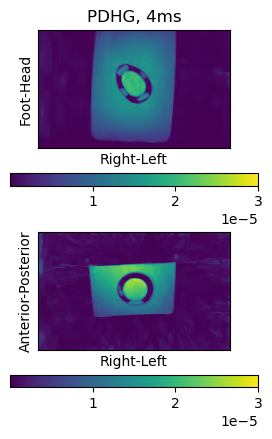

In [ ]:
im = pdhg_2.get_output().as_array()

%matplotlib inline
plot_rpe_3d([im],
            [59, 64],
            [f'PDHG, {Nms}ms'],
            [3*10**(-5)],
            'PDHG, 4ms.png')

## MCIR with SPDHG

In [24]:
# reuse the same TV instance
# G = alpha * FGP_TV(device='cpu', nonnegativity=False)
# G.proximal = types.MethodType(new_proximal, G)

start = datetime.now()
spdhg_2 = SPDHG(
            f = F, g = G, operator = A, 
            max_iteration = n_epochs*Nms, 
            update_objective_interval = Nms)
  

In [25]:
sc = functools.partial(saveCallback, spdhg_2, f"SPDHG_TV_{Nms:02d}ms", os.path.join(data_path, recons, f'MS_{Nms}'))
    
start = datetime.now()
spdhg_2.run(15*Nms, verbose=2, callback=sc)

spdhg_2.update_objective_interval = 5 * Nms
spdhg_2.run(5 * Nms, verbose=2, callback=sc)


spdhg_2.update_objective_interval = 10 * Nms
spdhg_2.run(verbose=2, callback=sc)
end = datetime.now()

spdhg_2_time = end-start

save_itrobj(spdhg_2, data_path, recons, Nms)

     Iter   Max Iter     Time/Iter        Primal          Dual     Primal-Dual
                               [s]     Objective     Objective             Gap
        0        600         0.000    1.69328e-02  -0.00000e+00    1.69328e-02
        6        600        18.264    1.43237e-03 6.45640e-04+2.32800e-05j7.86732e-04-2.32800e-05j
       12        600        18.672    1.07744e-03 5.81149e-04-3.28177e-05j4.96293e-04+3.28177e-05j
       18        600        18.640    1.01501e-03 4.27279e-04+7.90143e-07j5.87730e-04-7.90143e-07j
       24        600        18.656    7.92449e-04 3.05328e-04+5.43534e-06j4.87121e-04-5.43534e-06j
       30        600        18.828    6.70774e-04 2.37418e-04-3.48391e-07j4.33356e-04+3.48391e-07j
       36        600        18.926    6.12914e-04 2.11834e-04-1.96846e-05j4.01080e-04+1.96846e-05j
       42        600        18.945    5.91642e-04 2.32660e-04-1.70832e-05j3.58983e-04+1.70832e-05j
       48        600        18.957    5.80727e-04 2.64354e-04+1.49885e

In [ ]:
im = spdhg_2.get_output().as_array()

%matplotlib inline
plot_rpe_3d([im],
            [59, 64],
            [f'SPDHG, {Nms}ms'],
            [3*10**(-5)],
            f'SPDHG, {Nms}ms.png')

In [23]:
pdhg_2_time.seconds/3600

3.801111111111111

In [27]:
spdhg_2_time.seconds/3600

4.308611111111111

In [ ]:
print("That's all folks!")

In [ ]:
pdhg_2.iterations

In [31]:
# FISTA 
from cil.optimisation.functions import LeastSquares

F_all_subs = []
norms = spdhg_2.norms

for i in range(len(acq_ms_block.containers)):
    fi = LeastSquares(A=C[i], b=acq_ms_block[i], c=omega)
    # Use pre computed A norm to calculate the Lipschitz constant
    # https://github.com/TomographicImaging/CIL/blob/2b3e2cd393c7ae15e27a7539c144c5197afbacef/Wrappers/Python/cil/optimisation/functions/LeastSquares.py#L135C13-L135C64
    fi.L = 2.0 * np.abs(fi.c) * (norms[i]**2)
    print (fi.L)
    F_all_subs.append(fi)

from cil.optimisation.functions import SumFunction
Fi = SumFunction(*F_all_subs)
x_init = C[i].domain_geometry().allocate( 0.0 )


248.48376420674902
257.239365114387
243.27409258198526
241.51312233177103
254.9328470717427
235.483486285472


/opt/SIRF-SuperBuild/INSTALL/python/cil/optimisation/functions/LeastSquares.py:123: UserWarning: You should set the Lipschitz constant with calculate_Lipschitz().
  warnings.warn("You should set the Lipschitz constant with calculate_Lipschitz().")


In [32]:
fista_2 = FISTA(f=Fi, g=G, initial=x_init, max_iteration = n_epochs, 
            update_objective_interval = 1)


In [33]:
sc = functools.partial(saveCallback, fista_2, f"FISTA_TV_{Nms:02d}ms", os.path.join(data_path, recons, f'MS_{Nms}'))
    
start = datetime.now()
fista_2.run(15, verbose=2, callback=sc)

fista_2.update_objective_interval = 5 
fista_2.run(5, verbose=2, callback=sc)


fista_2.update_objective_interval = 10
fista_2.run(verbose=2, callback=sc)
end = datetime.now()
save_itrobj(fista_2, data_path, recons, Nms)

     Iter   Max Iter     Time/Iter        Primal          Dual     Primal-Dual
                               [s]     Objective     Objective             Gap
        0        100         0.000    1.69328e-02                             
        1        100        92.620    5.55819e-03                             
        2        100        93.012    4.11380e-03                             
        3        100        92.788    3.02118e-03                             
        4        100        92.636    2.16055e-03                             
        5        100        92.393    1.54557e-03                             
        6        100        92.569    1.14450e-03                             
        7        100        92.566    9.01926e-04                             
        8        100        92.437    7.62157e-04                             
        9        100        92.386    6.81562e-04                             
       10        100        92.366    6.31952e-04   